<h2 style="color: white; font-size: 22px; text-align: center;">
  Random Forest estandarizado diario
</h2>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_log_error
from sklearn.metrics import r2_score  

In [ ]:
datos = pd.read_csv("/home/santiago/Desktop/PROYECTO_RF/ESTANDARIZADO/DATOS_1/df_RobustScaler_diario.csv")
datos["fecha"] = pd.to_datetime(datos["fecha"])

In [3]:
def crear_features(df, variables):
    df = df.copy()

    for var in variables:

        for lag in [1, 3, 7, 14]:
            df[f"{var}_lag{lag}"] = df[var].shift(lag)

        #diferencias
        df[f"{var}_diff1"] = df[var] - df[var].shift(1)
        df[f"{var}_diff7"] = df[var] - df[var].shift(7)

        #medias moviles
        df[f"{var}_ma7"] = df[var].rolling(7).mean()
        df[f"{var}_ma14"] = df[var].rolling(14).mean()

        #tendencia
        df[f"{var}_trend7"] = df[var].rolling(7).apply(
            lambda x: np.polyfit(range(len(x)), x, 1)[0],
            raw=True
        )

    df = df.dropna().reset_index(drop=True)
    return df

In [ ]:
def modelo_random_forest(dataframe, variable_objetivo):

    print("=" * 60)
    print(f"Modelo para predecir: {variable_objetivo}")
    print("=" * 60)

   #separar datos de entrenamiento y prueba
    X = dataframe.drop(columns=["fecha", variable_objetivo])
    y = dataframe[variable_objetivo]

    #separacion temporal
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        shuffle=False
    )

    # Fechas del conjunto de prueba
    fechas_test = dataframe["fecha"].iloc[len(X_train):]

    #random forest
    modelo = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=42
    )

    modelo.fit(X_train, y_train)

    #prediccion
    pred = modelo.predict(X_test)

    residuos = y_test - pred
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    print(f"RMSE = {rmse:.3f}")
    print(f"MAE = {mae:.3f}")
    print(f"R2 = {r2:.3f}")

    #importancia de variables
    importancia = pd.DataFrame({
        "Variable": X.columns,
        "Importancia": modelo.feature_importances_
    }).sort_values("Importancia", ascending=False)

    print("\nTop variables:")
    print(importancia.head(10))

    #grafica
    plt.figure(figsize=(12,5))

    plt.plot(fechas_test, y_test.values, label="Real")
    plt.plot(fechas_test, pred, label="Predicción")

    plt.title(f"Random Forest - {variable_objetivo}")
    plt.xlabel("Fecha")
    plt.ylabel(variable_objetivo)

    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12,4))
    plt.plot(fechas_test, residuos)
    plt.axhline(0, color='red', linestyle='--')
    plt.title("Residuos")
    plt.grid(True)
    plt.show()

    return modelo

In [5]:
variables = [
    "pm25", "pm10", "nox", "so2",
    "no2", "o3", "co", "rh",
    "wsp", "wdr", "tmp", "pa"
]

datos_feat = crear_features(datos, variables)

/tmp/ipykernel_16195/2992172389.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_trend7"] = df[var].rolling(7).apply(
/tmp/ipykernel_16195/2992172389.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_lag{lag}"] = df[var].shift(lag)
/tmp/ipykernel_16195/2992172389.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragme

Modelo para predecir: pm25
RMSE = 0.257
MAE = 0.178

Top variables:
       Variable  Importancia
10           pa     0.728001
16   pm25_diff7     0.088544
13    pm25_lag7     0.045302
17     pm25_ma7     0.023497
15   pm25_diff1     0.010800
7           wsp     0.008501
11    pm25_lag1     0.006902
18    pm25_ma14     0.006379
19  pm25_trend7     0.004921
8           wdr     0.002000


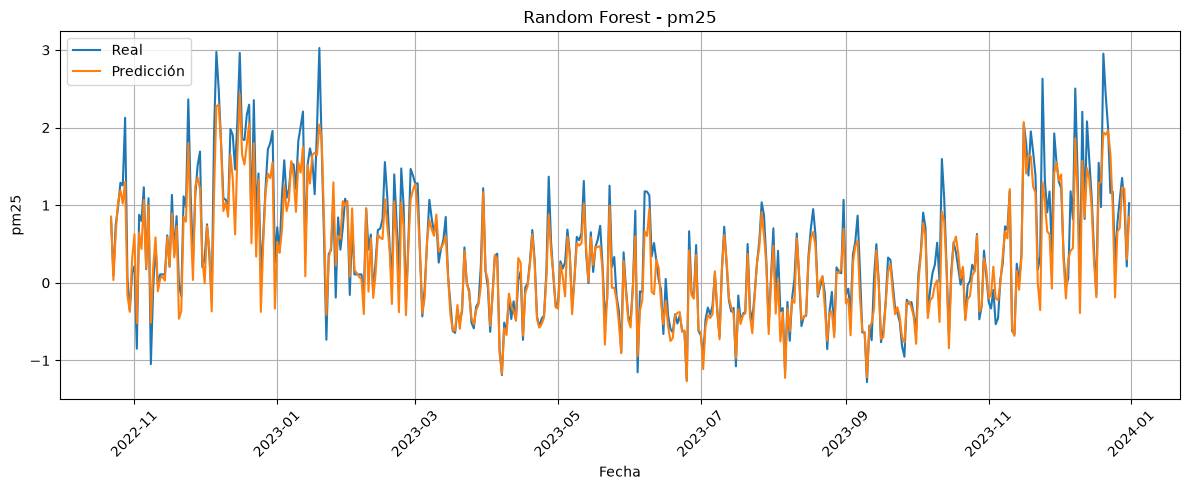

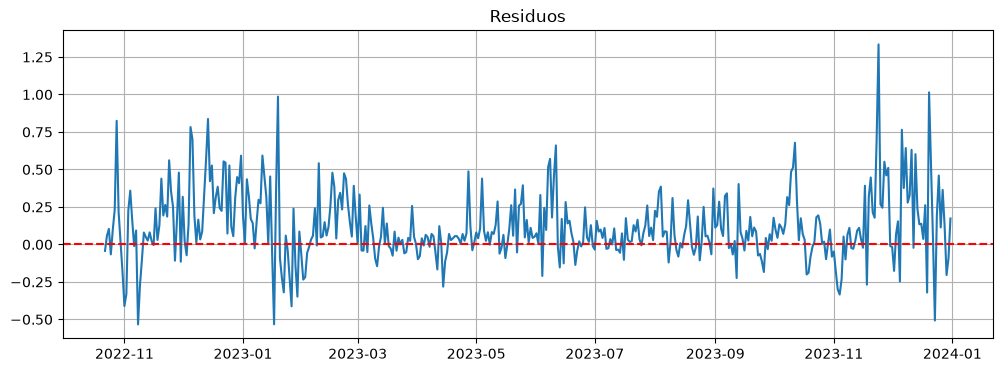

In [6]:
modelo_random_forest(datos_feat, "pm25")
print()

Modelo para predecir: nox
RMSE = 0.188
MAE = 0.118

Top variables:
       Variable  Importancia
34    nox_diff7     0.530635
31     nox_lag7     0.089771
33    nox_diff1     0.086615
35      nox_ma7     0.082991
29     nox_lag1     0.066847
37   nox_trend7     0.035206
36     nox_ma14     0.017782
7           wsp     0.017401
0          pm25     0.006386
117     pa_ma14     0.005734


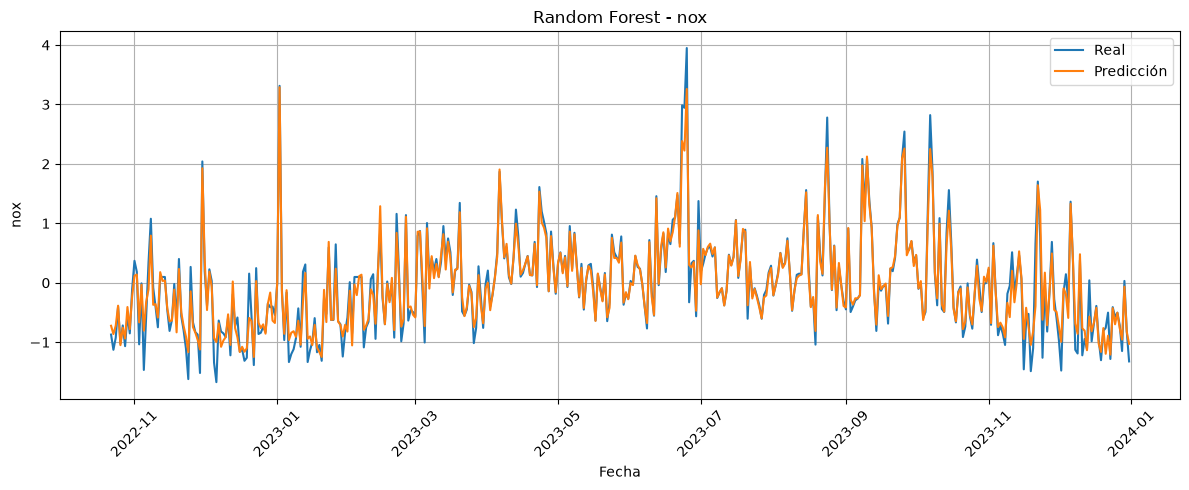

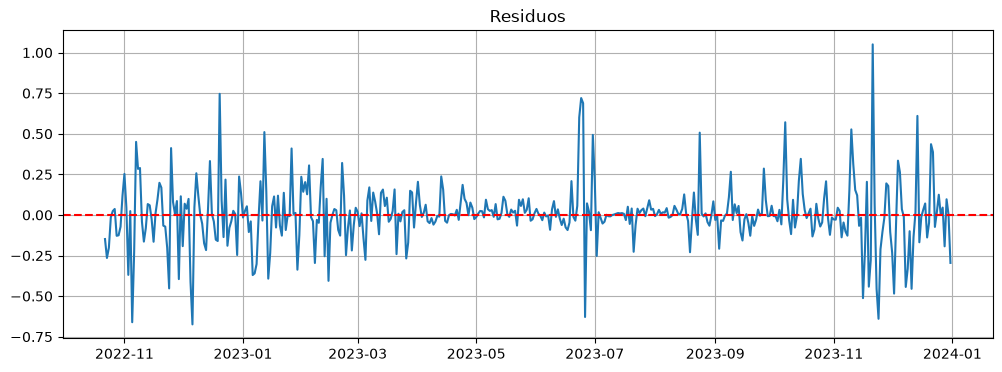

In [7]:
modelo_random_forest(datos_feat, "nox")
print()

Modelo para predecir: o3
RMSE = 0.070
MAE = 0.045

Top variables:
     Variable  Importancia
56    o3_lag1     0.554102
60   o3_diff1     0.197672
62     o3_ma7     0.169184
61   o3_diff7     0.030238
4         no2     0.009284
58    o3_lag7     0.006616
64  o3_trend7     0.003931
63    o3_ma14     0.002835
1        pm10     0.001702
51  no2_diff1     0.001050


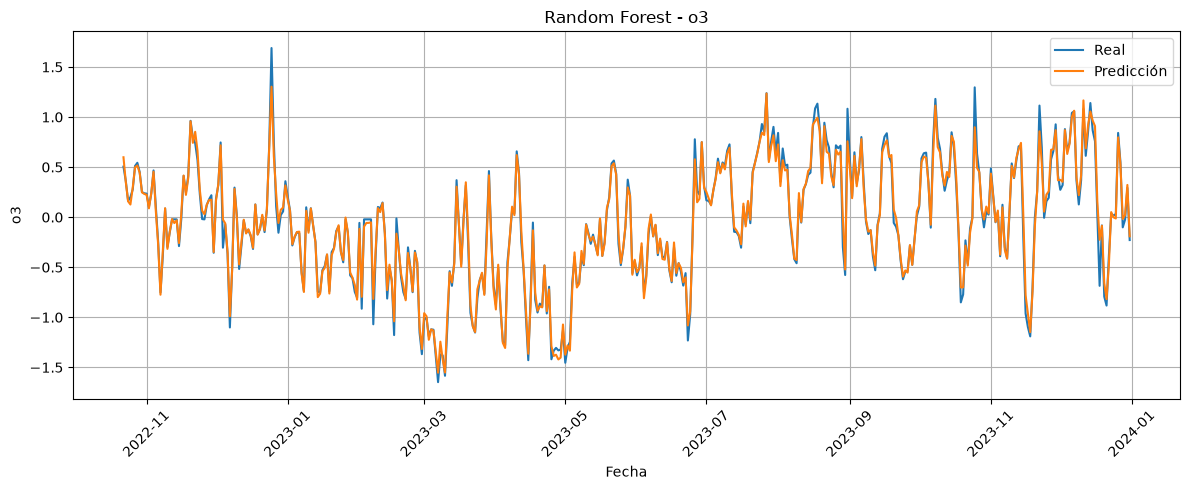

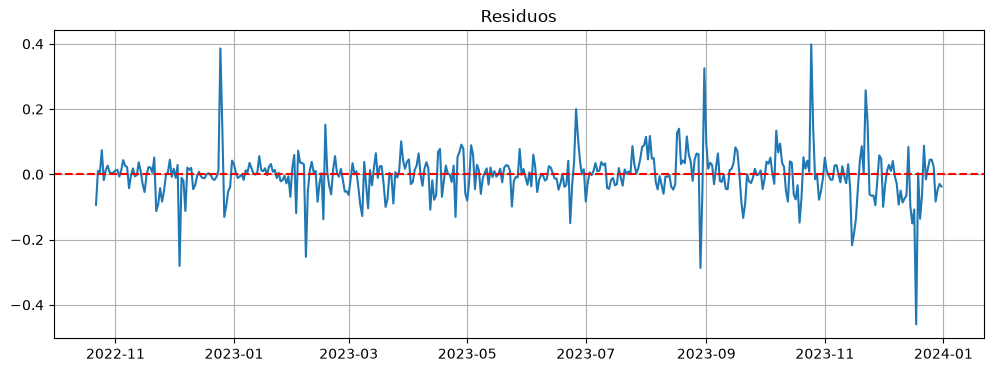

In [8]:
modelo_random_forest(datos_feat, "o3")
print()